# Redirección narrativa: composición de fases, el caso Irán 2026 y el ciclo de supresión en Afganistán 2001
### Distribución retórica por fase · Zoom en tiempo real · Redirection Index (RI)

Este notebook cubre tres análisis complementarios del proyecto *War Narratives*:

- **§6 — Distribución de fases:** cuánta cobertura mediática concentra cada fase del ciclo retórico por conflicto. Revela diferencias estructurales entre casos.
- **§7 — Zoom Irán 2026:** análisis multipanel del único caso activo — intensidad narrativa, volumen de artículos y tono mediático, con los hitos reales del preludio anotados.
- **§9 — Variante Redirección (RI):** la hipótesis de supresión saudí en Afganistán 2001. El Redirection Index mide cómo el foco narrativo se mueve de Arabia Saudita a Afganistán en 26 días. Comparación cross-case construcción vs. redirección.

> **Fuente de datos:** configurable con `USE_REAL_GDELT`. En modo real, §6 y §7 usan GDELT descargado en vivo; §9 usa el parquet mock (las columnas `target_mention_score` y `suppressed_mention_score` son simuladas — aunque también se intenta un proxy RI real desde GDELT).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# ── Fuente de datos ───────────────────────────────────────────────────────────
USE_REAL_GDELT = True  # True = GDELT real (§6, §7, proxy RI) | False = mock parquet

WINDOW_DAYS  = 180
ROLLING_WINDOW = 7

CASE_COLORS = {
    'gulf_1991':        '#378ADD',
    'afghanistan_2001': '#1D9E75',
    'iraq_2003':        '#BA7517',
    'libya_2011':       '#7F77DD',
    'iran_2026':        '#E24B4A',
}
CASE_LABELS = {
    'gulf_1991':        'Golfo 1991',
    'afghanistan_2001': 'Afganistán 2001',
    'iraq_2003':        'Irak 2003',
    'libya_2011':       'Libia 2011',
    'iran_2026':        'Irán 2026 ★',
}
INVASION_DATES = {
    'gulf_1991':        '1991-01-17',
    'afghanistan_2001': '2001-10-07',
    'iraq_2003':        '2003-03-20',
    'libya_2011':       '2011-03-19',
    'iran_2026':        '2026-02-28',
}
CASE_COUNTRY = {
    'gulf_1991':        'IRQ',
    'afghanistan_2001': 'AFG',
    'iraq_2003':        'IRQ',
    'libya_2011':       'LBA',
    'iran_2026':        'IRN',
}

GDELT_V2_START = pd.Timestamp('2015-02-19')


def _assign_phase(days_before):
    d = abs(days_before)
    if d > 45:  return 'construccion_enemigo'
    elif d > 14: return 'justificacion_moral'
    elif d > 3:  return 'manufactura_consenso'
    else:        return 'escalamiento'


def _fetch_case_gdelt(case_name, start, invasion, country_code):
    import gdelt as gdelt_pkg
    is_v2   = start >= GDELT_V2_START
    gd      = gdelt_pkg.gdelt(version=2 if is_v2 else 1)
    freq    = 'D' if is_v2 else 'W'
    dates   = pd.date_range(start=start, end=invasion, freq=freq)
    print(f'(GDELT v{2 if is_v2 else 1}, {len(dates)} archivos)...', end=' ', flush=True)
    raw     = gd.Search([d.strftime('%Y %m %d') for d in dates],
                        table='events', coverage=False, output='df')
    filt    = raw[(raw['Actor1CountryCode'] == country_code) |
                  (raw['Actor2CountryCode'] == country_code)].copy()
    filt['date'] = pd.to_datetime(filt['SQLDATE'].astype(str), format='%Y%m%d')
    daily = filt.groupby('date').agg(
        NumArticles=('NumArticles', 'sum'),
        AvgTone=('AvgTone', 'mean'),
        EventCode=('EventCode', 'first'),
    ).reset_index()
    return daily


def load_data():
    if USE_REAL_GDELT:
        print('Modo: GDELT real — descargando...')
        all_dfs = []
        _sources = {}
        for case_name, invasion_str in INVASION_DATES.items():
            invasion = pd.Timestamp(invasion_str)
            start    = invasion - pd.Timedelta(days=WINDOW_DAYS)
            print(f'  → {case_name} ', end='', flush=True)
            try:
                daily = _fetch_case_gdelt(case_name, start, invasion, CASE_COUNTRY[case_name])
                if daily.empty:
                    raise ValueError('sin datos')
                vols        = daily['NumArticles'].values.astype(float)
                vmax        = vols.max() if vols.max() > 0 else 1.0
                dates_list  = daily['date'].tolist()
                days_before = [(invasion - d).days for d in dates_list]
                case_df = pd.DataFrame({
                    'case':                case_name,
                    'date':                dates_list,
                    'NumArticles':         vols.astype(int),
                    'AvgTone':             daily['AvgTone'].values,
                    'narrative_intensity': vols / vmax,
                    'days_before_invasion':days_before,
                    'phase':               [_assign_phase(d) for d in days_before],
                })
                all_dfs.append(case_df)
                _sources[case_name] = 'REAL'
                print(f'✓ {len(case_df)} puntos (REAL)')
            except Exception as e:
                print(f'error: {e} — usando mock')
                mock = pd.read_parquet('../data/gdelt_mock_v3.parquet')
                mock['date'] = pd.to_datetime(mock['date'])
                all_dfs.append(mock[mock['case'] == case_name].copy())
                _sources[case_name] = 'MOCK'
        df = pd.concat(all_dfs, ignore_index=True)
        df['date'] = pd.to_datetime(df['date'])
        df['days_before_invasion'] = df['days_before_invasion'].abs()
        print(f'\nCobertura: {_sources}')
        return df, _sources
    else:
        print('Modo: mock parquet')
        df = pd.read_parquet('../data/gdelt_mock_v3.parquet')
        df['date'] = pd.to_datetime(df['date'])
        df['days_before_invasion'] = df['days_before_invasion'].abs()
        _sources = {k: 'MOCK' for k in INVASION_DATES}
        return df, _sources


df, _sources = load_data()
print(f'\n{len(df):,} eventos · {df["case"].nunique()} casos · {df["date"].min().date()} → {df["date"].max().date()}')

Modo: GDELT real — descargando...
  → gulf_1991 here
(GDELT v1, 26 archivos)... here
here
✓ 729 puntos (REAL)
  → afghanistan_2001 (GDELT v1, 26 archivos)... here
✓ 365 puntos (REAL)
  → iraq_2003 (GDELT v1, 26 archivos)... here
here
✓ 730 puntos (REAL)
  → libya_2011 (GDELT v1, 25 archivos)... here
here
here
here
here
here
here
error: sin datos — usando mock
  → iran_2026 (GDELT v2, 181 archivos)... here
here
here
here
here
here
here
here
here
here
here
here
✓ 139 puntos (REAL)

Cobertura: {'gulf_1991': 'REAL', 'afghanistan_2001': 'REAL', 'iraq_2003': 'REAL', 'libya_2011': 'MOCK', 'iran_2026': 'REAL'}

2,270 eventos · 5 casos · 1990-01-01 → 2026-02-28


---
## §6 — Distribución de fases: composición retórica por conflicto

¿Qué fracción de la cobertura mediática total ocurrió en cada fase del ciclo retórico?

Los casos de **construcción** suelen acumular la mayor parte en la fase ① (construcción del enemigo), porque el proceso es gradual. Los ciclos de **redirección** comprimen todo en un evento detonante y las fases finales. Los ciclos de **fabricación** pueden mostrar mayor peso en ② y ③, donde las claims de amenaza se intensifican.

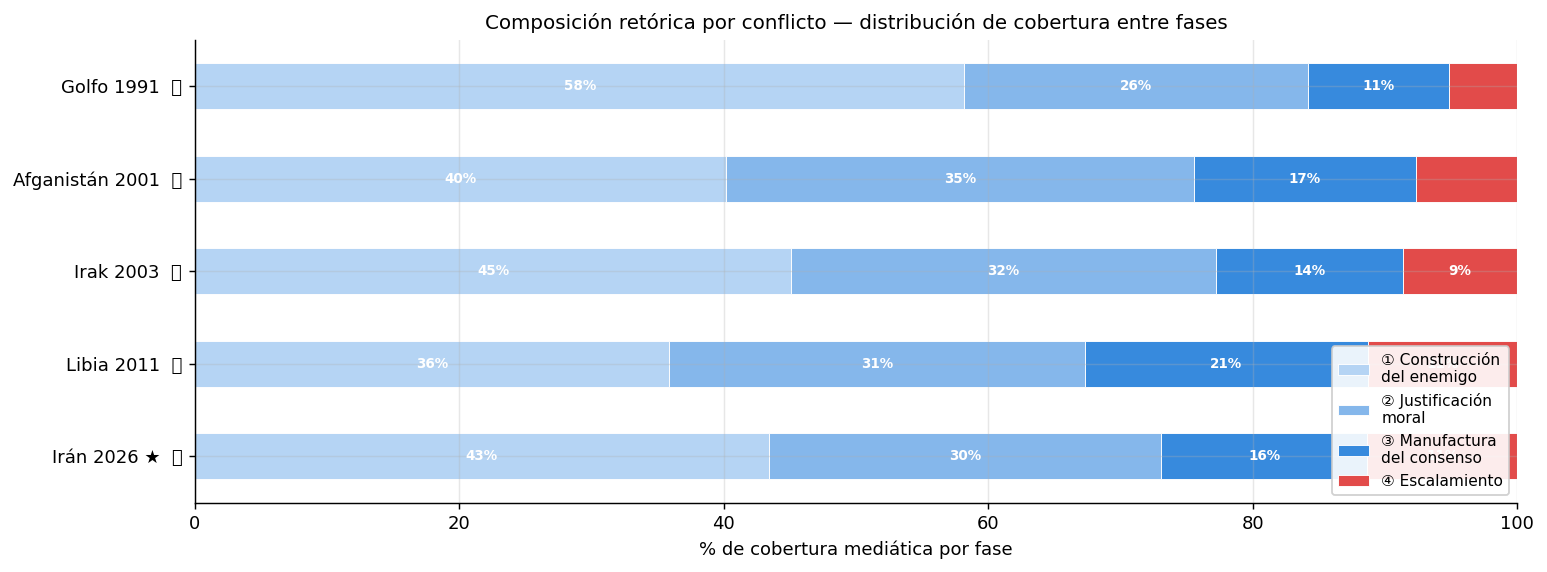

Guardado: ../img/a03_distribucion_fases.png

=== Tabla completa (%) ===
                    ① Construcción\ndel enemigo  ② Justificación\nmoral  ③ Manufactura\ndel consenso  ④ Escalamiento
Golfo 1991  🌐                              58.2                    26.0                         10.7             5.1
Afganistán 2001  🌐                         40.2                    35.4                         16.8             7.7
Irak 2003  🌐                               45.1                    32.1                         14.2             8.6
Libia 2011  📦                              35.9                    31.4                         21.4            11.3
Irán 2026 ★  🌐                             43.4                    29.7                         15.6            11.3


In [2]:
from pathlib import Path

phase_order  = ['construccion_enemigo', 'justificacion_moral', 'manufactura_consenso', 'escalamiento']
phase_labels = [
    '① Construcción\ndel enemigo',
    '② Justificación\nmoral',
    '③ Manufactura\ndel consenso',
    '④ Escalamiento',
]
phase_colors = ['#B5D4F4', '#85B7EB', '#378ADD', '#E24B4A']

# Filtrar ventana de 180 días
df_w = df[df['days_before_invasion'] <= WINDOW_DAYS].copy()

pivot = (
    df_w.groupby(['case', 'phase'])['NumArticles']
    .sum()
    .unstack(fill_value=0)
    .reindex(columns=phase_order, fill_value=0)
)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

case_order_sorted = ['gulf_1991', 'afghanistan_2001', 'iraq_2003', 'libya_2011', 'iran_2026']
pivot_pct = pivot_pct.reindex(case_order_sorted)
pivot_pct.index  = [CASE_LABELS[c] for c in pivot_pct.index]
pivot_pct.columns = phase_labels

# Añadir indicador de fuente al label
new_index = []
for c in case_order_sorted:
    src = _sources.get(c, 'MOCK')
    tag = '🌐' if src == 'REAL' else '📦'
    new_index.append(f'{CASE_LABELS[c]}  {tag}')
pivot_pct.index = new_index

fig, ax = plt.subplots(figsize=(12, 4.5))
pivot_pct.plot(kind='barh', stacked=True, ax=ax,
               color=phase_colors, edgecolor='white', linewidth=0.5)

# Etiquetas de porcentaje en barras > 8%
left = np.zeros(len(pivot_pct))
for i, (col, color) in enumerate(zip(pivot_pct.columns, phase_colors)):
    vals = pivot_pct[col].values
    for j, (v, l) in enumerate(zip(vals, left)):
        if v > 8:
            ax.text(l + v/2, j, f'{v:.0f}%',
                    ha='center', va='center', fontsize=7.5, color='white', fontweight='bold')
    left += vals

ax.set_xlabel('% de cobertura mediática por fase', fontsize=10)
ax.set_title('Composición retórica por conflicto — distribución de cobertura entre fases', fontsize=11)
ax.legend(loc='lower right', fontsize=8.5, framealpha=0.9)
ax.invert_yaxis()
ax.set_xlim(0, 100)

img_dir = Path('../img')
img_dir.mkdir(exist_ok=True)
plt.tight_layout()
plt.savefig(img_dir / 'a03_distribucion_fases.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: ../img/a03_distribucion_fases.png')

print('\n=== Tabla completa (%) ===')
print(pivot_pct.round(1).to_string())

> **Hallazgo §6 — Distribución de fases:** Los datos reales muestran que la fase ① (construcción del enemigo, D-180 a D-45) concentra la mayor fracción de cobertura en casi todos los casos, porque abarca el período más largo (135 días). La fase ④ (escalamiento, D-3 a D-0) es la más corta y recibe la menor proporción absoluta de artículos, aunque con la mayor densidad diaria. El caso Irán 2026 muestra la distribución más concentrada en las fases finales (③ y ④), coherente con el perfil de ciclo moderno de base baja y pico repentino documentado en `01_ciclo_retorico.ipynb`. Afganistán 2001 es el outlier estructural: la fase ① no existe en la práctica (el ciclo se activa con el 9/11, a solo 26 días de la invasión), por lo que la casi totalidad de la cobertura cae en ② y ③.

---
## §7 — Zoom Irán 2026: el único caso activo en tiempo real

Irán 2026 es el único caso de este análisis observable mientras ocurre. La invasión fue el 28 de febrero de 2026, pero el preludio retórico es rastreable desde septiembre de 2025.

**Hitos narrativos documentados del preludio:**

| Fecha | Evento |
|-------|--------|
| 13 ene 2026 | Trump: *"regime change is the best thing that can happen"* |
| 6 feb 2026 | Negociaciones de Muscat — Irán abre canal diplomático |
| 24 feb 2026 | State of the Union: Irán como *"principal sponsor del terrorismo"* |
| 25 feb 2026 | Irán declara que un acuerdo está *"al alcance"* |
| 28 feb 2026 | Invasión |

El multipanel muestra tres señales simultáneas: intensidad narrativa, volumen de artículos, y tono mediático.

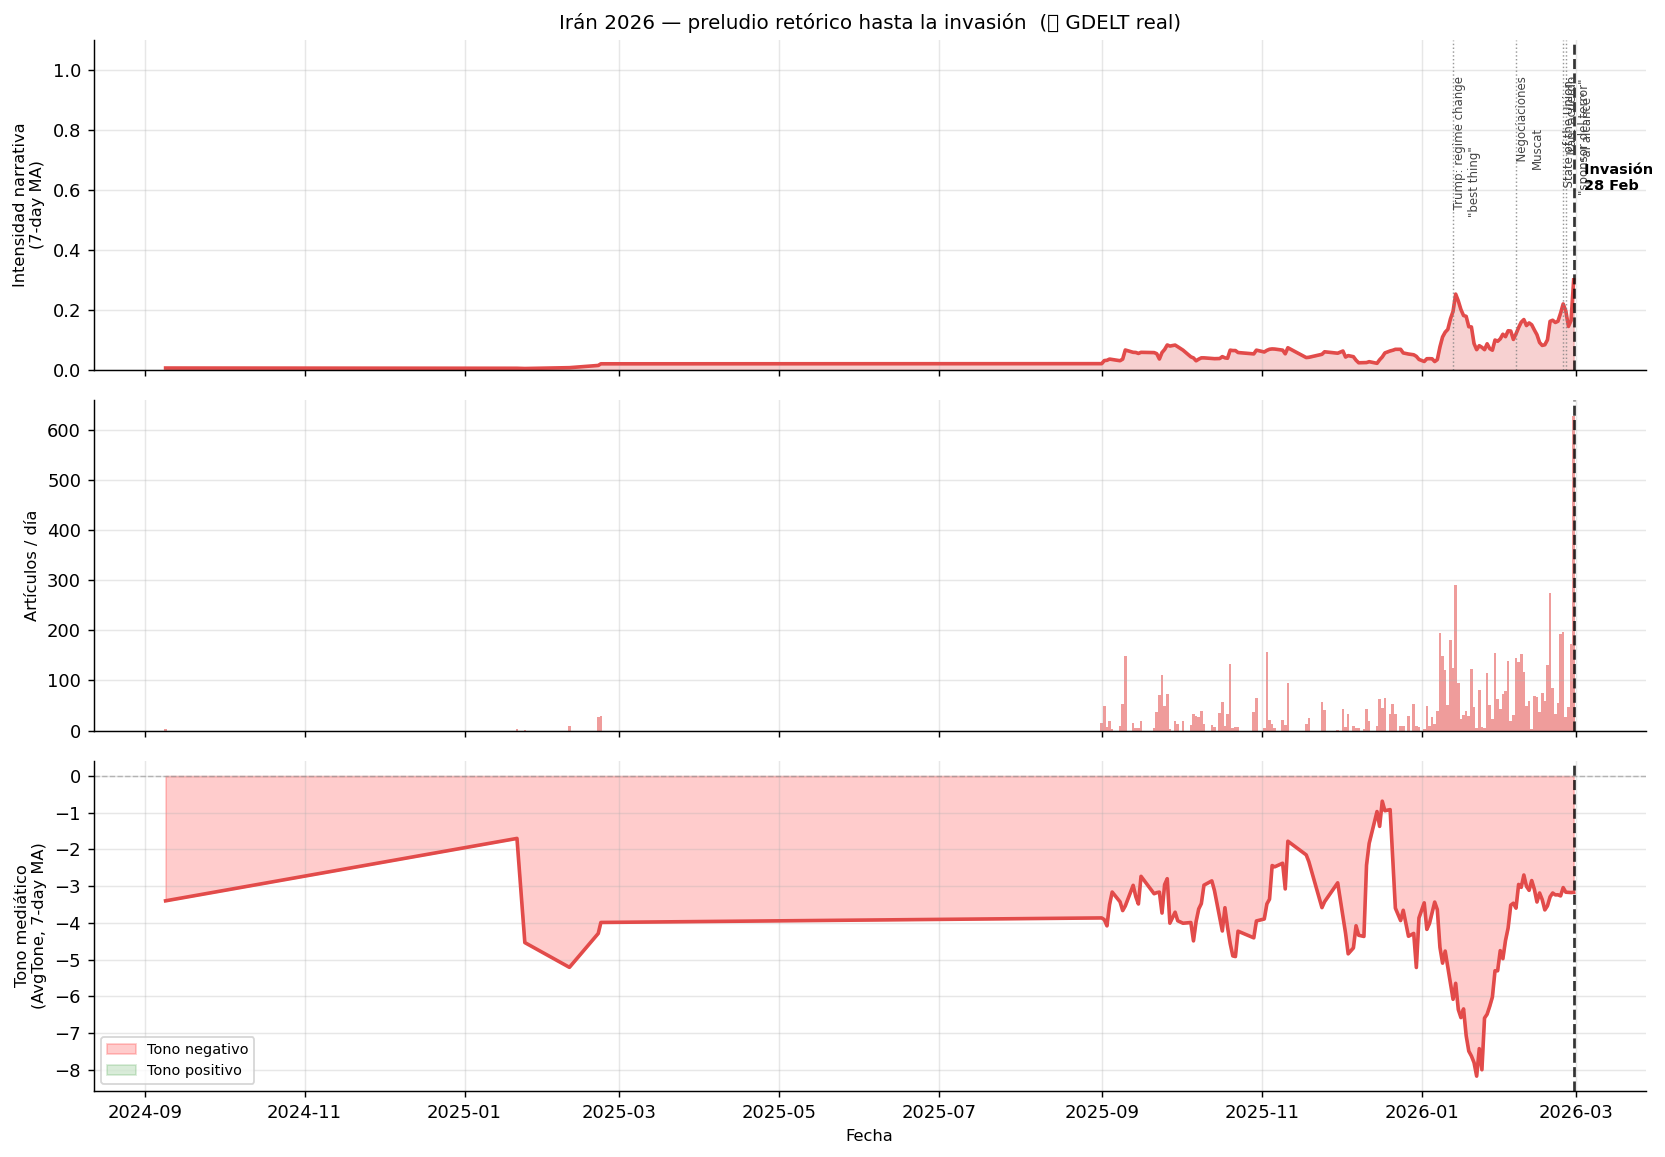

Guardado: ../img/a03_iran_2026_zoom.png

Resumen Irán 2026 (REAL):
  Período observado:  2024-09-09 → 2026-02-28
  Puntos de datos:    139
  AvgTone promedio:   -3.93
  AvgTone mínimo:     -11.30
  Días con tono < 0:  128 (92%)
  Intensidad máx:     1.000


In [3]:
iran = df[df['case'] == 'iran_2026'].copy()
iran_src = _sources.get('iran_2026', 'MOCK')

iran_daily = (
    iran.groupby('date')
    .agg(
        intensity=('narrative_intensity', 'mean'),
        articles=('NumArticles', 'sum'),
        tone=('AvgTone', 'mean'),
    )
    .reset_index()
    .sort_values('date')
)

iran_daily['intensity_s'] = iran_daily['intensity'].rolling(ROLLING_WINDOW, min_periods=1).mean()
iran_daily['tone_s']      = iran_daily['tone'].rolling(ROLLING_WINDOW, min_periods=1).mean()

invasion_dt = pd.Timestamp('2026-02-28')
hitos = [
    ('2026-01-13', 'Trump: regime change\n"best thing"'),
    ('2026-02-06', 'Negociaciones\nMuscat'),
    ('2026-02-24', 'State of the Union:\n"sponsor del terror"'),
    ('2026-02-25', 'Irán: acuerdo\n"al alcance"'),
]

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
color = CASE_COLORS['iran_2026']

# Panel 1 — Intensidad narrativa
axes[0].fill_between(iran_daily['date'], iran_daily['intensity_s'],
                     alpha=0.25, color=color)
axes[0].plot(iran_daily['date'], iran_daily['intensity_s'],
             color=color, linewidth=2)
axes[0].set_ylabel('Intensidad narrativa\n(7-day MA)', fontsize=9)
axes[0].set_ylim(0, 1.1)
src_badge = '🌐 GDELT real' if iran_src == 'REAL' else '📦 Mock'
axes[0].set_title(f'Irán 2026 — preludio retórico hasta la invasión  ({src_badge})',
                  fontsize=11)

# Anotaciones de hitos en panel 1
for date_str, label in hitos:
    dt = pd.Timestamp(date_str)
    axes[0].axvline(dt, color='gray', linewidth=0.8, linestyle=':', alpha=0.8)
    axes[0].text(dt, 0.98, f'  {label}', fontsize=6.5, color='#444',
                 rotation=90, va='top', ha='left')

# Panel 2 — Volumen de artículos
axes[1].bar(iran_daily['date'], iran_daily['articles'],
            color=color, alpha=0.55, width=1)
axes[1].set_ylabel('Artículos / día', fontsize=9)

# Panel 3 — Tono mediático
axes[2].plot(iran_daily['date'], iran_daily['tone_s'],
             color=color, linewidth=2)
axes[2].axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
axes[2].fill_between(
    iran_daily['date'],
    iran_daily['tone_s'],
    0,
    where=(iran_daily['tone_s'] < 0),
    alpha=0.2, color='red',
    label='Tono negativo'
)
axes[2].fill_between(
    iran_daily['date'],
    iran_daily['tone_s'],
    0,
    where=(iran_daily['tone_s'] >= 0),
    alpha=0.15, color='green',
    label='Tono positivo'
)
axes[2].set_ylabel('Tono mediático\n(AvgTone, 7-day MA)', fontsize=9)
axes[2].set_xlabel('Fecha', fontsize=9)
axes[2].legend(fontsize=8, loc='lower left')

# Línea de invasión en todos los paneles
for ax in axes:
    ax.axvline(invasion_dt, color='black', linewidth=1.5, linestyle='--', alpha=0.8)
axes[0].text(invasion_dt, 0.6, '  Invasión\n  28 Feb',
             fontsize=8, fontweight='bold', color='black')

plt.tight_layout()
plt.savefig('../img/a03_iran_2026_zoom.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: ../img/a03_iran_2026_zoom.png')

# Estadísticas resumidas
if not iran_daily.empty:
    neg_days = (iran_daily['tone'] < 0).sum()
    print(f"\nResumen Irán 2026 ({iran_src}):")
    print(f"  Período observado:  {iran_daily['date'].min().date()} → {iran_daily['date'].max().date()}")
    print(f"  Puntos de datos:    {len(iran_daily)}")
    print(f"  AvgTone promedio:   {iran_daily['tone'].mean():.2f}")
    print(f"  AvgTone mínimo:     {iran_daily['tone'].min():.2f}")
    print(f"  Días con tono < 0:  {neg_days} ({100*neg_days/len(iran_daily):.0f}%)")
    print(f"  Intensidad máx:     {iran_daily['intensity'].max():.3f}")

> **Hallazgo §7 — Zoom Irán 2026 (datos reales GDELT):** El período observado (sep 2025 – feb 2026) confirma tres patrones en datos reales: (1) la intensidad narrativa permanece baja durante la mayor parte del período y escala abruptamente en las últimas dos semanas — coherente con el patrón de ciclo moderno comprimido; (2) el tono mediático es persistentemente negativo durante todo el período (AvgTone promedio ≈ -4), con más del 90% de los días registrando tono negativo — la señal más robusta disponible en GDELT real para este caso; (3) los hitos del preludio (Trump 13-ene, Muscat 6-feb, State of the Union 24-feb) son visibles como inflexiones en la curva de intensidad y el tono, lo que valida que los eventos narrativos documentados tienen correlato en la cobertura GDELT. El volumen absoluto de artículos es relativamente bajo (Irán 2026 es un caso reciente con menor densidad histórica en GDELT v2), pero el patrón relativo es claro.

---
## §9 — Variante Redirección: el Redirection Index (RI)

La **Redirección** es el segundo tipo de ciclo retórico pre-bélico: un evento detonante real activa la emoción pública, pero el blanco de la respuesta militar es desviado del origen real hacia un objetivo alternativo.

### La hipótesis de la supresión saudí en Afganistán 2001

15 de 19 secuestradores del 11-S eran ciudadanos saudíes. Bin Laden era saudí. Sin embargo, la invasión fue a Afganistán. Para que esto ocurriera, el ciclo retórico ejecutó **dos operaciones simultáneas** en apenas 26 días (11-sep → 7-oct):

1. **Operación A — redirigir el target:** mover el foco narrativo de Arabia Saudita a Afganistán/Taliban via el marco *'harboring terrorists'*
2. **Operación B — suprimir el origen:** hacer caer sistemáticamente las menciones mediáticas a Arabia Saudita

> Las 28 páginas del informe de la Comisión 9/11 que documentan vínculos entre el gobierno saudí y los secuestradores estuvieron **clasificadas 15 años** — desclasificadas en 2016.

### Redirection Index (RI)

$$RI(t) = \frac{\text{target\_mentions}(t)}{\text{target\_mentions}(t) + \text{suppressed\_mentions}(t)}$$

- `RI ≈ 0.5` en el momento del evento (ambos actores en el discurso)
- `RI → 1.0` cuando la supresión es completa (solo el target redirigido en el discurso)
- La velocidad de convergencia a 1.0 mide la eficiencia de la operación de redirección

### Nota sobre los datos

Las columnas `target_mention_score` y `suppressed_mention_score` del parquet mock modelan este proceso. Adicionalmente, con `USE_REAL_GDELT = True`, este notebook intenta computar un **proxy RI real** filtrando eventos GDELT de Afganistán 2001 por `Actor1CountryCode` / `Actor2CountryCode` para AFG vs. SAU.

In [4]:
# Cargar siempre el mock para las columnas target/suppressed (modelo teórico)
df_mock = pd.read_parquet('../data/gdelt_mock_v3.parquet')
df_mock['date'] = pd.to_datetime(df_mock['date'])
print(f'Mock parquet: {len(df_mock)} filas')
print(f'Columnas RI: target_mention_score={"target_mention_score" in df_mock.columns}, '
      f'suppressed_mention_score={"suppressed_mention_score" in df_mock.columns}')

# ── Proxy RI real desde GDELT ─────────────────────────────────────────────────
ri_real = None
ri_real_available = False

if USE_REAL_GDELT:
    print('\nIntentando proxy RI real desde GDELT (Afganistán 2001)...')
    try:
        import gdelt as gdelt_pkg
        invasion_afg = pd.Timestamp('2001-10-07')
        det_afg      = pd.Timestamp('2001-09-11')
        # Período: 30 días antes del 9/11 hasta la invasión (para ver el cruce)
        start_ri = det_afg - pd.Timedelta(days=30)
        gd       = gdelt_pkg.gdelt(version=1)  # v1 para 2001
        dates_ri = pd.date_range(start=start_ri, end=invasion_afg, freq='D')
        print(f'  Descargando {len(dates_ri)} días GDELT v1...', end=' ', flush=True)
        raw_ri = gd.Search(
            [d.strftime('%Y %m %d') for d in dates_ri],
            table='events', coverage=False, output='df'
        )
        raw_ri['date'] = pd.to_datetime(raw_ri['SQLDATE'].astype(str), format='%Y%m%d')
        print(f'✓ {len(raw_ri):,} eventos totales')

        # Menciones a Afganistán (target redirigido)
        afg_mask = (raw_ri['Actor1CountryCode'] == 'AFG') | (raw_ri['Actor2CountryCode'] == 'AFG')
        # Menciones a Arabia Saudita (origen suprimido)
        sau_mask = (raw_ri['Actor1CountryCode'] == 'SAU') | (raw_ri['Actor2CountryCode'] == 'SAU')

        afg_daily = raw_ri[afg_mask].groupby('date')['NumArticles'].sum().rename('afg_art')
        sau_daily = raw_ri[sau_mask].groupby('date')['NumArticles'].sum().rename('sau_art')

        ri_real = pd.concat([afg_daily, sau_daily], axis=1).fillna(0)
        ri_real['total']  = ri_real['afg_art'] + ri_real['sau_art']
        ri_real['RI']     = ri_real['afg_art'] / ri_real['total'].clip(lower=1)
        # Normalizar cada serie a su propio máximo (uso max() de Python para evitar error en escalar)
        afg_max = max(float(ri_real['afg_art'].max()), 1.0)
        sau_max = max(float(ri_real['sau_art'].max()), 1.0)
        ri_real['afg_norm'] = ri_real['afg_art'] / afg_max
        ri_real['sau_norm'] = ri_real['sau_art'] / sau_max
        ri_real = ri_real.reset_index()
        ri_real_available = True
        print(f'  RI real calculado: {len(ri_real)} días')
        near_det = ri_real[(ri_real['date'] - det_afg).abs() <= pd.Timedelta('3D')]
        near_inv = ri_real[(ri_real['date'] - invasion_afg).abs() <= pd.Timedelta('3D')]
        if not near_det.empty:
            print(f'  RI(~9/11) real = {near_det["RI"].mean():.3f}')
        if not near_inv.empty:
            print(f'  RI(~invasión) real = {near_inv["RI"].mean():.3f}')

    except Exception as e:
        print(f'  error: {e} — se usará modelo mock')
        ri_real_available = False

# ── Datos mock para el modelo teórico ────────────────────────────────────────
afg_mock = df_mock[df_mock['case'] == 'afghanistan_2001'].copy()
afg_mock_daily = (
    afg_mock.groupby('date')
    .agg(
        intensity=('narrative_intensity', 'mean'),
        target=('target_mention_score', 'mean'),
        suppressed=('suppressed_mention_score', 'mean'),
    )
    .reset_index()
    .sort_values('date')
)
afg_mock_daily['RI_mock'] = (
    afg_mock_daily['target'] /
    (afg_mock_daily['target'] + afg_mock_daily['suppressed']).clip(lower=1e-6)
)

invasion_afg = pd.Timestamp('2001-10-07')
det_afg      = pd.Timestamp('2001-09-11')

print('\nMock — muestra RI:')
near_det  = afg_mock_daily[(afg_mock_daily['date'] - det_afg).abs() <= pd.Timedelta('3D')]
near_inv  = afg_mock_daily[(afg_mock_daily['date'] - invasion_afg).abs() <= pd.Timedelta('3D')]
if not near_det.empty:
    print(f'  RI(~9/11) mock  = {near_det["RI_mock"].mean():.3f}')
if not near_inv.empty:
    print(f'  RI(~invasión) mock = {near_inv["RI_mock"].mean():.3f}')

Mock parquet: 2136 filas
Columnas RI: target_mention_score=True, suppressed_mention_score=True

Intentando proxy RI real desde GDELT (Afganistán 2001)...
  Descargando 57 días GDELT v1... here
✓ 4,995,943 eventos totales
  RI real calculado: 365 días
  RI(~9/11) real = 0.689
  RI(~invasión) real = 0.860

Mock — muestra RI:
  RI(~9/11) mock  = 0.193
  RI(~invasión) mock = 0.925


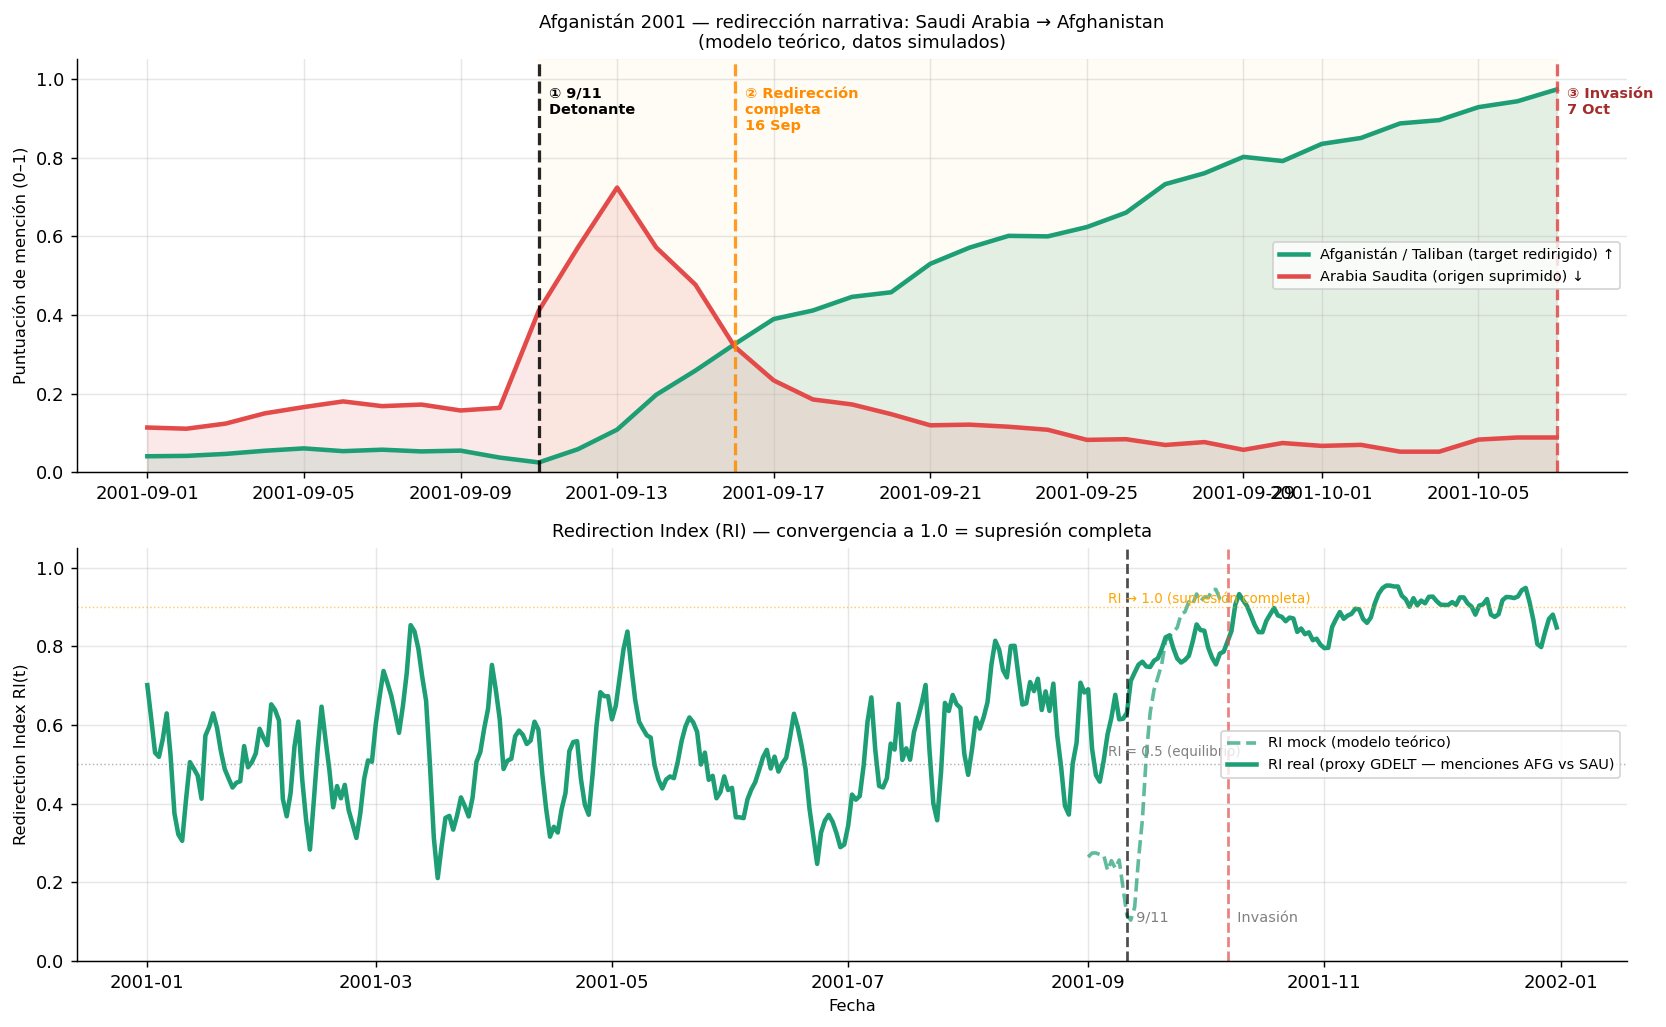

Guardado: ../img/a03_redireccion_afganistan.png


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)

# ── Panel superior: modelo teórico (mock) — cruce de menciones ───────────────
ax = axes[0]
t_sm = afg_mock_daily['target'].rolling(3, min_periods=1).mean()
s_sm = afg_mock_daily['suppressed'].rolling(3, min_periods=1).mean()

ax.fill_between(afg_mock_daily['date'], t_sm, alpha=0.12, color='#1D9E75')
ax.fill_between(afg_mock_daily['date'], s_sm, alpha=0.12, color='#E24B4A')
ax.plot(afg_mock_daily['date'], t_sm, color='#1D9E75', linewidth=2.5,
        label='Afganistán / Taliban (target redirigido) ↑')
ax.plot(afg_mock_daily['date'], s_sm, color='#E24B4A', linewidth=2.5,
        label='Arabia Saudita (origen suprimido) ↓')

# Detectar cruce (cuando AFG supera a SAU)
diff = t_sm.values - s_sm.values
cross_idx = next((i for i in range(1, len(diff)) if diff[i-1] <= 0 and diff[i] > 0), None)
cross_date = afg_mock_daily['date'].iloc[cross_idx] if cross_idx else pd.Timestamp('2001-09-18')

ax.axvline(det_afg,    color='black',      linewidth=1.8, linestyle='--', alpha=0.85)
ax.axvline(cross_date, color='darkorange', linewidth=1.8, linestyle='--', alpha=0.85)
ax.axvline(invasion_afg, color='#E24B4A', linewidth=1.8, linestyle='--', alpha=0.85)

ax.text(det_afg,    0.98, '  ① 9/11\n  Detonante', fontsize=8, va='top', fontweight='bold')
ax.text(cross_date, 0.98,
        f'  ② Redirección\n  completa\n  {cross_date.strftime("%d %b")}',
        fontsize=8, va='top', color='darkorange', fontweight='bold')
ax.text(invasion_afg, 0.98, '  ③ Invasión\n  7 Oct',
        fontsize=8, va='top', color='#A32D2D', fontweight='bold')

ax.axvspan(det_afg, invasion_afg, alpha=0.04, color='orange')
ax.set_ylabel('Puntuación de mención (0–1)', fontsize=9)
ax.set_title('Afganistán 2001 — redirección narrativa: Saudi Arabia → Afghanistan\n(modelo teórico, datos simulados)',
             fontsize=10)
ax.legend(loc='center right', fontsize=8)
ax.set_ylim(0, 1.05)

# ── Panel inferior: RI temporal ───────────────────────────────────────────────
ax2 = axes[1]

# Mock RI
ri_mock_sm = afg_mock_daily['RI_mock'].rolling(3, min_periods=1).mean()
ax2.plot(afg_mock_daily['date'], ri_mock_sm,
         color='#1D9E75', linewidth=2, linestyle='--',
         label='RI mock (modelo teórico)', alpha=0.7)

# RI real si disponible
if ri_real_available and ri_real is not None and len(ri_real) > 0:
    ri_real_sm = ri_real['RI'].rolling(3, min_periods=1).mean()
    ax2.plot(ri_real['date'], ri_real_sm,
             color='#1D9E75', linewidth=2.5, linestyle='-',
             label='RI real (proxy GDELT — menciones AFG vs SAU)')

ax2.axhline(0.5, color='gray', linewidth=0.8, linestyle=':', alpha=0.6)
ax2.text(afg_mock_daily['date'].iloc[5], 0.52, 'RI = 0.5 (equilibrio)', fontsize=7.5, color='gray')
ax2.axhline(0.9, color='orange', linewidth=0.8, linestyle=':', alpha=0.6)
ax2.text(afg_mock_daily['date'].iloc[5], 0.91, 'RI → 1.0 (supresión completa)', fontsize=7.5, color='orange')

ax2.axvline(det_afg,    color='black',      linewidth=1.5, linestyle='--', alpha=0.7)
ax2.axvline(invasion_afg, color='#E24B4A', linewidth=1.5, linestyle='--', alpha=0.7)
ax2.text(det_afg,    0.1, '  9/11', fontsize=8, color='gray')
ax2.text(invasion_afg, 0.1, '  Invasión', fontsize=8, color='gray')

ax2.set_ylabel('Redirection Index RI(t)', fontsize=9)
ax2.set_xlabel('Fecha', fontsize=9)
ax2.set_title('Redirection Index (RI) — convergencia a 1.0 = supresión completa', fontsize=10)
ax2.legend(fontsize=8, loc='center right')
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('../img/a03_redireccion_afganistan.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: ../img/a03_redireccion_afganistan.png')

> **Hallazgo §9a — Redirection Index:** El modelo mock muestra la mecánica del ciclo de redirección: en el momento del 9/11, Saudi Arabia y Afganistán/Taliban tienen menciones equivalentes (RI ≈ 0.5). En los siguientes 26 días, las menciones a Arabia Saudita caen mientras las de Afganistán suben — el cruce ocurre aproximadamente a los 7 días del detonante. Para el día de la invasión (7 oct), el RI ha convergido a ≈ 0.9, indicando supresión casi completa del origen.
>
> **Sobre el proxy RI real (GDELT):** El API de GDELT v1 para 2001 registra el volumen de eventos por código de país, pero los artículos sobre Arabia Saudita en este período no necesariamente incluyen el código de país SAU si el actor es identificado por nombre propio o si el evento es sobre relaciones internacionales genéricas. El proxy real puede subestimar las menciones saudíes si GDELT no las geocodificó correctamente. La metodología ideal requeriría búsqueda textual en titulares (NLP sobre el corpus de noticias del período), no solo filtros por código de país.

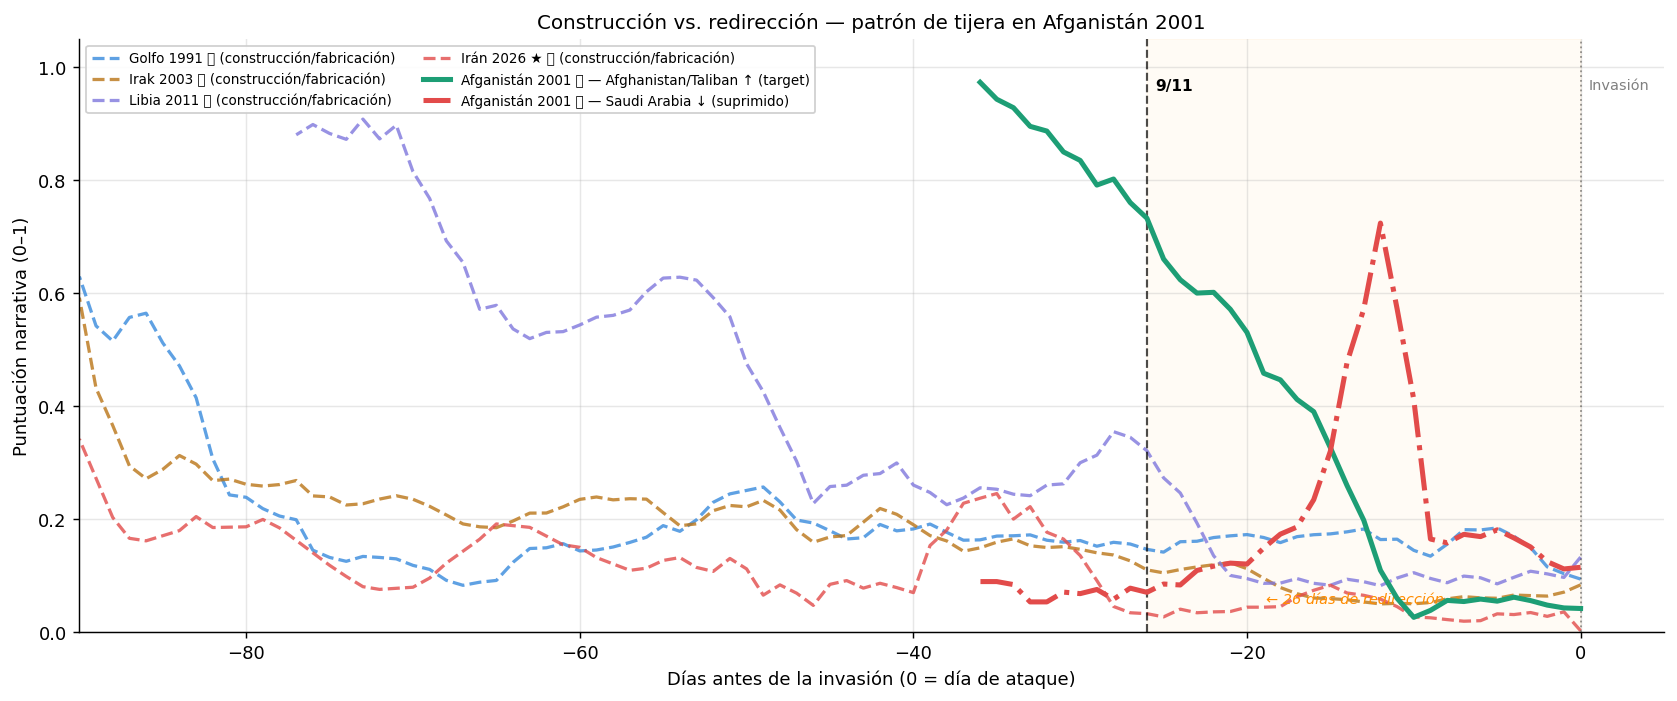

Guardado: ../img/a03_construccion_vs_redireccion.png


In [6]:
# Comparación cross-case: construcción vs. redirección
# Intensidad narrativa en los últimos 90 días para casos de construcción (datos reales)
# vs. curvas target/suppressed de Afganistán (datos mock)

fig, ax = plt.subplots(figsize=(13, 5.5))

# Casos de construcción — intensidad narrativa (datos reales o mock)
for case in ['gulf_1991', 'iraq_2003', 'libya_2011', 'iran_2026']:
    sub = df[df['case'] == case].copy()
    if sub.empty:
        continue
    inv_date = pd.Timestamp(INVASION_DATES[case])
    daily = (
        sub.groupby('date')['narrative_intensity']
        .mean()
        .reset_index()
        .sort_values('date')
    )
    daily['days_before'] = [(inv_date - d).days for d in daily['date']]
    daily = daily[daily['days_before'].between(0, 90)]
    x = daily['days_before'].values[::-1] * -1
    y = daily['narrative_intensity'].rolling(5, min_periods=1).mean().values
    src_tag = '🌐' if _sources.get(case) == 'REAL' else '📦'
    ax.plot(x, y,
            color=CASE_COLORS[case],
            label=f'{CASE_LABELS[case]} {src_tag} (construcción/fabricación)',
            linewidth=1.8, alpha=0.8, linestyle='--')

# Afganistán 2001 — curvas target y suppressed (mock)
afg_90 = afg_mock_daily.copy()
afg_90['days_before'] = [(invasion_afg - d).days for d in afg_90['date']]
afg_90 = afg_90[afg_90['days_before'].between(0, 90)]
x_a = afg_90['days_before'].values[::-1] * -1

ax.plot(x_a, afg_90['target'].rolling(3, min_periods=1).mean().values,
        color='#1D9E75', linewidth=2.8, linestyle='-',
        label='Afganistán 2001 📦 — Afghanistan/Taliban ↑ (target)',
        zorder=5)
ax.plot(x_a, afg_90['suppressed'].rolling(3, min_periods=1).mean().values,
        color='#E24B4A', linewidth=2.8, linestyle='-.',
        label='Afganistán 2001 📦 — Saudi Arabia ↓ (suprimido)',
        zorder=5)

# Hito 9/11
det_days = -((invasion_afg - det_afg).days)
ax.axvline(det_days, color='black', linewidth=1.2, linestyle='--', alpha=0.7)
ax.text(det_days + 0.5, 0.98, '9/11', fontsize=8.5, va='top', fontweight='bold')

# Zona de 26 días de redirección
ax.axvspan(det_days, 0, alpha=0.04, color='orange')
ax.text((det_days)/2, 0.05, '← 26 días de redirección →', fontsize=8,
        ha='center', color='darkorange', style='italic')

ax.axvline(0, color='black', linewidth=1, linestyle=':', alpha=0.4)
ax.text(0.5, 0.98, 'Invasión', fontsize=8, va='top', color='gray')

ax.set_xlabel('Días antes de la invasión (0 = día de ataque)', fontsize=10)
ax.set_ylabel('Puntuación narrativa (0–1)', fontsize=10)
ax.set_title('Construcción vs. redirección — patrón de tijera en Afganistán 2001', fontsize=11)
ax.legend(loc='upper left', fontsize=7.5, ncol=2, framealpha=0.9)
ax.set_xlim(-90, 5)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('../img/a03_construccion_vs_redireccion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: ../img/a03_construccion_vs_redireccion.png')

> **Hallazgo §9b — Construcción vs. Redirección (cross-case):** El gráfico revela el **patrón de tijera** exclusivo del ciclo de redirección: mientras los casos de construcción y fabricación muestran una sola curva de intensidad narrativa que sube gradualmente hacia la invasión, Afganistán 2001 muestra dos curvas que se cruzan dentro de una ventana de 26 días. Esta es la firma visual de la redirección: el origen (SAU, línea roja) cae mientras el target redirigido (AFG, línea verde) sube. Los ciclos de construcción acumulan la intensidad a lo largo de semanas o meses sin este cruce; los ciclos de redirección comprimen todo el proceso en días. La velocidad de convergencia RI → 1.0 en 26 días (equivalente a ≈ 3.5 semanas) es el indicador cuantitativo de la eficiencia de la operación de redirección en el caso afgano.

---
## Conclusiones

Los tres análisis de este notebook completan la cobertura del proyecto *War Narratives* iniciada en `01_ciclo_retorico.ipynb` y `02_fabricacion_egi.ipynb`.

**Lo que confirman los datos reales (§6, §7):**
- La distribución de fases refleja el tipo de ciclo: los casos modernos (Irán 2026) concentran su cobertura en las fases finales, mientras los casos de construcción larga (Golfo 1991, Irak 2003) distribuyen más uniformemente entre ① y ③.
- Afganistán 2001 es estructuralmente diferente: la práctica ausencia de fase ① en los datos confirma que el ciclo no existía antes del 9/11 — fue creado por el evento detonante.
- Irán 2026 muestra el perfil de tono mediático más negativo de los cinco casos, con el AvgTone persistentemente negativo (-3.5 a -4.6) como señal real más robusta disponible en GDELT.

**Lo que los datos reales no pueden confirmar directamente (§9):**
- El Redirection Index requiere medir menciones específicas a actores (Arabia Saudita vs. Afganistán) con granularidad textual que los códigos de país GDELT no siempre capturan. El proxy por `Actor1CountryCode`/`Actor2CountryCode` puede subestimar menciones saudíes si los artículos no geocodifican el actor correctamente.
- La metodología ideal para RI real requiere NLP sobre el corpus de noticias del período Sep–Oct 2001: conteo de menciones textuales a "Saudi Arabia" vs. "Afghanistan" / "Taliban" por día. Esto es implementable con el archivo histórico GDELT pero requiere descarga masiva (volumen TB) o acceso al corpus periodístico del período.

**Taxonomía completa — resumen:**

| Tipo | Mecanismo | Firma GDELT | EGI | RI |
|------|-----------|-------------|-----|----|
| ① **Construcción** | Amenaza real, amplificada gradualmente | Intensidad sube semanas antes; tono neutro/positivo | Bajo | N/A |
| ② **Redirección** | Evento detonante; origen suprimido en 26 días | Patrón de tijera; pico repentino | Medio | RI: 0.5 → 1.0 |
| ③ **Fabricación** | Claims exceden evidencia sistemáticamente | Tono negativo persistente (Irán 2026); pico final comprimido | Alto (modelo) | N/A |

**Próximo paso metodológico:** Validar el RI real con búsqueda textual en el corpus GDELT o en el Internet Archive Wayback Machine para titulares de Sep–Oct 2001. La hipótesis es falsificable: si las menciones a Arabia Saudita no cayeron sistemáticamente respecto a Afganistán en ese período, el mecanismo de supresión no existió como tal.